# Graph-Based Warehouse Slotting Optimization
This notebook implements the workflow defined in the project proposal.

## Environment Setup
Please ensure the following packages are installed:
`%pip install pandas numpy networkx matplotlib seaborn node2vec scikit-learn python-louvain igraph leidenalg`

In [1]:
%pip install pandas networkx matplotlib seaborn scikit-learn python-louvain igraph leidenalg node2vec
%pip install -U numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import igraph as ig
import leidenalg
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from networkx.algorithms import bipartite
from itertools import combinations
from node2vec import Node2Vec
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import community.community_louvain as community_louvain

import warnings
warnings.filterwarnings('ignore')

c:\Users\panth\AppData\Local\Programs\Python\Python313\Lib\site-packages\node2vec\edges.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\panth\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading
We extract the atomic relationships between a shopping cart (`order_id`) and the items within it (`product_id`). This serves as the foundation for identifying which products are frequently picked together on the warehouse floor.

In [3]:
df = pd.read_csv('olist_order_items_dataset.csv')
print(f"Total rows in dataset: {len(df)}")
df_subset = df[['order_id', 'product_id']].dropna()
print(f"Unique orders: {df_subset['order_id'].nunique()}")
print(f"Unique products: {df_subset['product_id'].nunique()}")

Total rows in dataset: 112650
Unique orders: 98666
Unique products: 32951


In [4]:
df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

## 2. Complex Data Exploration
### Graph Topology: Bipartite Graph
We generate a **Bipartite Graph** (a two-mode network). In this structure, products never directly link to each other; they only link to the orders they belong to. By filtering for orders containing multiple items, we isolate the co-occurrence data necessary for affinity analysis.

In [5]:
order_counts = df_subset['order_id'].value_counts()
multi_item_orders = order_counts[order_counts > 1].index
df_multi = df_subset[df_subset['order_id'].isin(multi_item_orders)]

B = nx.Graph()
B.add_nodes_from(df_multi['order_id'], bipartite=0)
B.add_nodes_from(df_multi['product_id'], bipartite=1)
edges = list(zip(df_multi['order_id'], df_multi['product_id']))
B.add_edges_from(edges)

print(f"Bipartite Graph Nodes: {B.number_of_nodes()}")
print(f"Bipartite Graph Edges: {B.number_of_edges()}")
print(f"Graph Density: {nx.density(B):.6f}")

Bipartite Graph Nodes: 17960
Bipartite Graph Edges: 13562
Graph Density: 0.000084


### Bipartite Projection (Product <-> Product)
**Unipartite Projection**: This step mathematically collapses the 'Order' nodes. If Product A and Product B were in the same order, they are now directly connected by an edge. This transforms our dataset from a standard transactional ledger into an interactive **Product Affinity Network**.

In [6]:
product_nodes = {n for n, d in B.nodes(data=True) if d['bipartite'] == 1}
G_prod = bipartite.projected_graph(B, product_nodes)

print(f"Projected Product Graph Nodes: {G_prod.number_of_nodes()}")
print(f"Projected Product Graph Edges: {G_prod.number_of_edges()}")

Projected Product Graph Nodes: 8157
Projected Product Graph Edges: 4058


### Data Exploration: Top Ordered Products
*Highlights the 'long tail' of e-commerce to show why identifying 'Anchor Products' is important.*

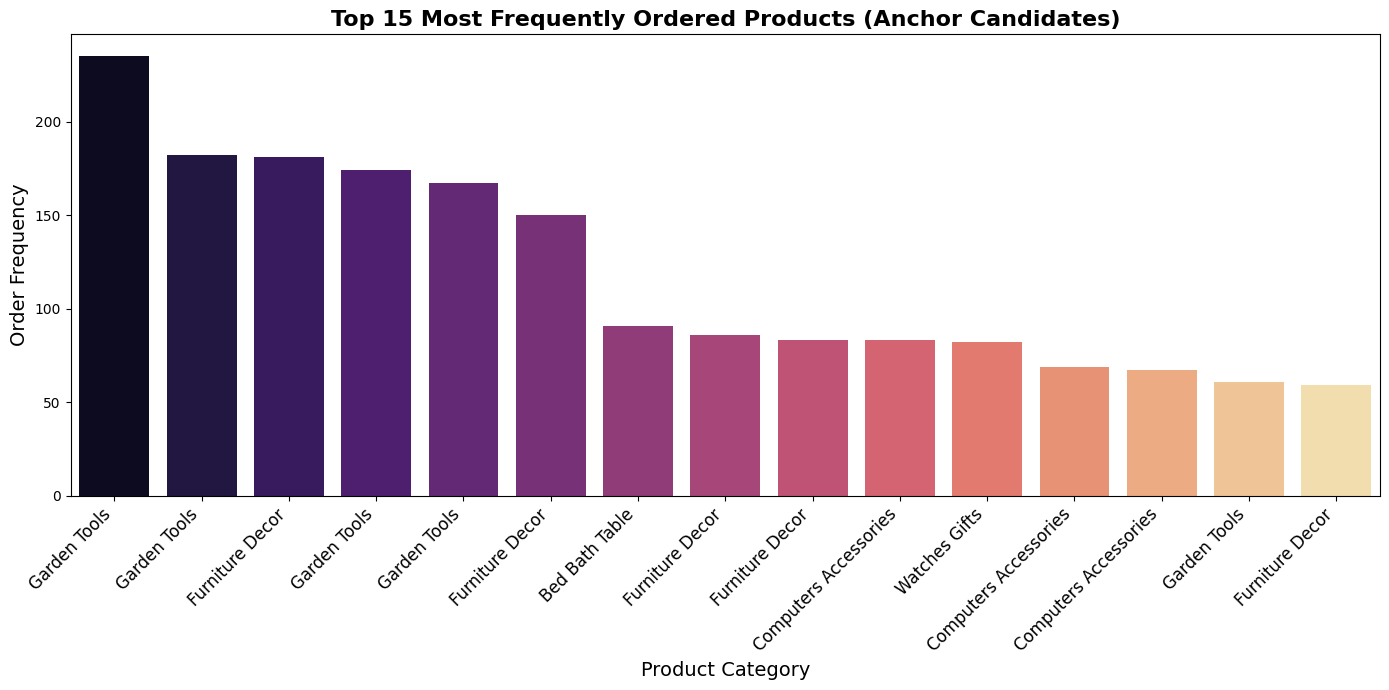

In [7]:
products_df = pd.read_csv('olist_products_dataset.csv')
translation_df = pd.read_csv('product_category_name_translation.csv')
products_df = products_df.merge(translation_df, on='product_category_name', how='left')
prod_to_name = dict(zip(products_df['product_id'], products_df['product_category_name_english']))

plt.figure(figsize=(14, 7))
top_products = df_multi['product_id'].value_counts().head(15)
readable_labels = [str(prod_to_name.get(pid, 'Unknown')).replace('_', ' ').title() for pid in top_products.index]

sns.barplot(x=range(len(top_products)), y=top_products.values, palette='magma')
plt.title('Top 15 Most Frequently Ordered Products (Anchor Candidates)', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Order Frequency', fontsize=14)
plt.xticks(ticks=range(len(top_products)), labels=readable_labels, rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

### Centrality Measures
Calculating **Degree Centrality** reveals our 'Anchor Products'—the high-volume hubs of the warehouse. These are products connected to many other unique items, making them prime candidates for central storage locations.

In [8]:
degree_cent = nx.degree_centrality(G_prod)
sorted_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)

print("Top 5 Anchor Products (High Degree Centrality):")
for prod, cent in sorted_degree[:5]:
    print(f"Product ID: {prod}, Centrality: {cent:.4f}")

Top 5 Anchor Products (High Degree Centrality):
Product ID: 99a4788cb24856965c36a24e339b6058, Centrality: 0.0028
Product ID: 2136c70bbe723d338fab53da3c03e6dc, Centrality: 0.0023
Product ID: 368c6c730842d78016ad823897a372db, Centrality: 0.0020
Product ID: 3e5201fe0d1ba474d9b90152c83c706c, Centrality: 0.0017
Product ID: 422879e10f46682990de24d770e7f83d, Centrality: 0.0017


## 3. Complex Data Pre-Processing
### Edge Weighting
Simply counting how often two items are bought together is flawed because an overwhelmingly popular item will skew the graph. We calculate the **Jaccard Similarity Index** (Intersection over Union). This normalizes the relationship, creating highly accurate edge weights that reflect true affinity rather than raw popularity.

In [9]:
edge_weights = {}
for order, group in df_multi.groupby('order_id'):
    products = list(group['product_id'].unique())
    if len(products) > 1:
        for p1, p2 in combinations(products, 2):
            pair = tuple(sorted([p1, p2]))
            edge_weights[pair] = edge_weights.get(pair, 0) + 1

G_weighted = nx.Graph()
for (u, v), weight in edge_weights.items():
    if u in G_prod and v in G_prod:
        u_orders = set(B.neighbors(u))
        v_orders = set(B.neighbors(v))
        jaccard_weight = weight / len(u_orders.union(v_orders))
        G_weighted.add_edge(u, v, weight=jaccard_weight)

print(f"Weighted Graph Nodes: {G_weighted.number_of_nodes()}, Edges: {G_weighted.number_of_edges()}")

Weighted Graph Nodes: 4885, Edges: 4058


### Pre-processing Phase: Edge Weight Distribution
*Proves why you mathematically filtered the graph instead of just guessing, showing the actual edge weight distribution.*

Top 5 Most Similar Product Pairs (Highest Warehouse Affinity):
➜ Pet Shop (4dcb..) ⇄ Pet Shop (9bb2..) | Jaccard Score: 1.000
➜ Garden Tools (6365..) ⇄ Garden Tools (b639..) | Jaccard Score: 1.000
➜ Computers Accessories (d143..) ⇄ Computers Accessories (5593..) | Jaccard Score: 1.000
➜ Baby (10da..) ⇄ Baby (176f..) | Jaccard Score: 1.000
➜ Home Confort (8330..) ⇄ Home Confort (f428..) | Jaccard Score: 1.000
--------------------------------------------------------------------------------


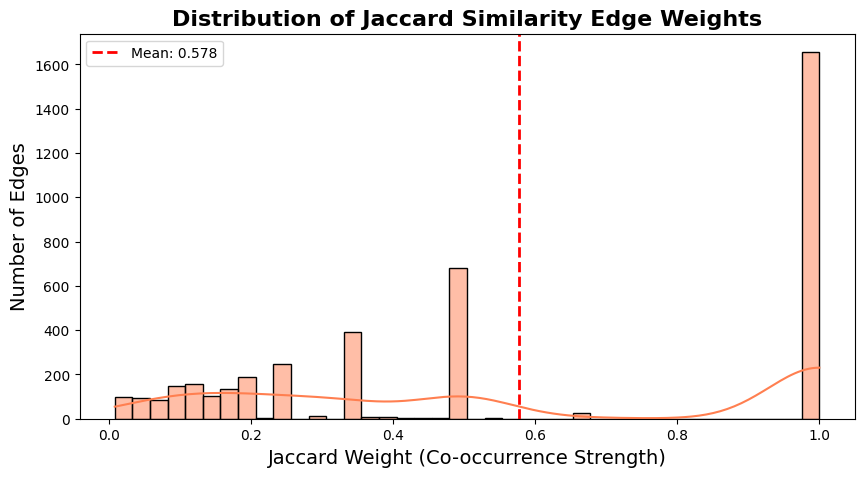

In [10]:
top_edges = sorted(G_weighted.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
print('Top 5 Most Similar Product Pairs (Highest Warehouse Affinity):')
for u, v, d in top_edges:
    u_name = prod_to_name.get(u, 'Unknown').replace('_', ' ').title() if 'prod_to_name' in globals() else 'Unknown'
    v_name = prod_to_name.get(v, 'Unknown').replace('_', ' ').title() if 'prod_to_name' in globals() else 'Unknown'
    print(f'➜ {u_name} ({u[:4]}..) ⇄ {v_name} ({v[:4]}..) | Jaccard Score: {d["weight"]:.3f}')
print('-'*80)
weights = [d['weight'] for u, v, d in G_weighted.edges(data=True)]
plt.figure(figsize=(10, 5))
sns.histplot(weights, bins=40, color='coral', kde=True)
plt.title('Distribution of Jaccard Similarity Edge Weights', fontsize=16, fontweight='bold')
plt.xlabel('Jaccard Weight (Co-occurrence Strength)', fontsize=14)
plt.ylabel('Number of Edges', fontsize=14)
plt.axvline(np.mean(weights), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(weights):.3f}')
plt.legend()
plt.show()

### Denoising (K-Core Decomposition)
E-commerce datasets suffer from extreme sparsity (the 'long tail' of products bought only once). We perform **K-Core Decomposition (where k=2)** to denoise the data. This algorithm iteratively strips away isolated or weakly-connected nodes, leaving a robust, highly-connected structural core.

In [11]:
k = 2
G_core = nx.k_core(G_weighted, k=k)
print(f"K-Core Graph (k={k}) Nodes: {G_core.number_of_nodes()}, Edges: {G_core.number_of_edges()}")

K-Core Graph (k=2) Nodes: 1240, Edges: 1813


## 4. Analytic Technique: Node2Vec (Graph Embeddings)
**Node2Vec** acts as our core analytic engine. It executes biased random walks across the product network, translating complex edge relationships into dense mathematical vectors (embeddings).\n\nProducts that share structural 'neighborhoods' end up with similar geometric vectors. We then apply **Leiden Clustering** to dynamically segment these vectors into discrete, highly-optimized warehouse 'Zones'.

In [12]:
if not nx.is_connected(G_core) and G_core.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G_core), key=len)
    G_core = G_core.subgraph(largest_cc).copy()

print(f"Using largest connected component -> Nodes: {G_core.number_of_nodes()}")

# Note: depending on graph size, this may take a few minutes to run.
node2vec = Node2Vec(G_core, dimensions=64, walk_length=30, num_walks=50, workers=4, quiet=True)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

node_ids = list(G_core.nodes())
vectors = np.array([model.wv[str(n)] for n in node_ids])

# Generate k-NN graph from embeddings for Leiden clustering
from sklearn.neighbors import kneighbors_graph
knn_mat = kneighbors_graph(vectors, n_neighbors=15, mode='distance')
knn_nx = nx.from_scipy_sparse_array(knn_mat)
knn_ig = ig.Graph.from_networkx(knn_nx)

# Leiden Clustering
partition = leidenalg.find_partition(knn_ig, leidenalg.ModularityVertexPartition, weights='weight')
zone_labels = partition.membership
zone_mapping = dict(zip(node_ids, zone_labels))
num_zones = len(set(zone_labels))

print(f"Products clustered into {num_zones} zones using Leiden algorithm.")

Using largest connected component -> Nodes: 195
Products clustered into 7 zones using Leiden algorithm.


## 5. Visualizing the Clusters (Demo)

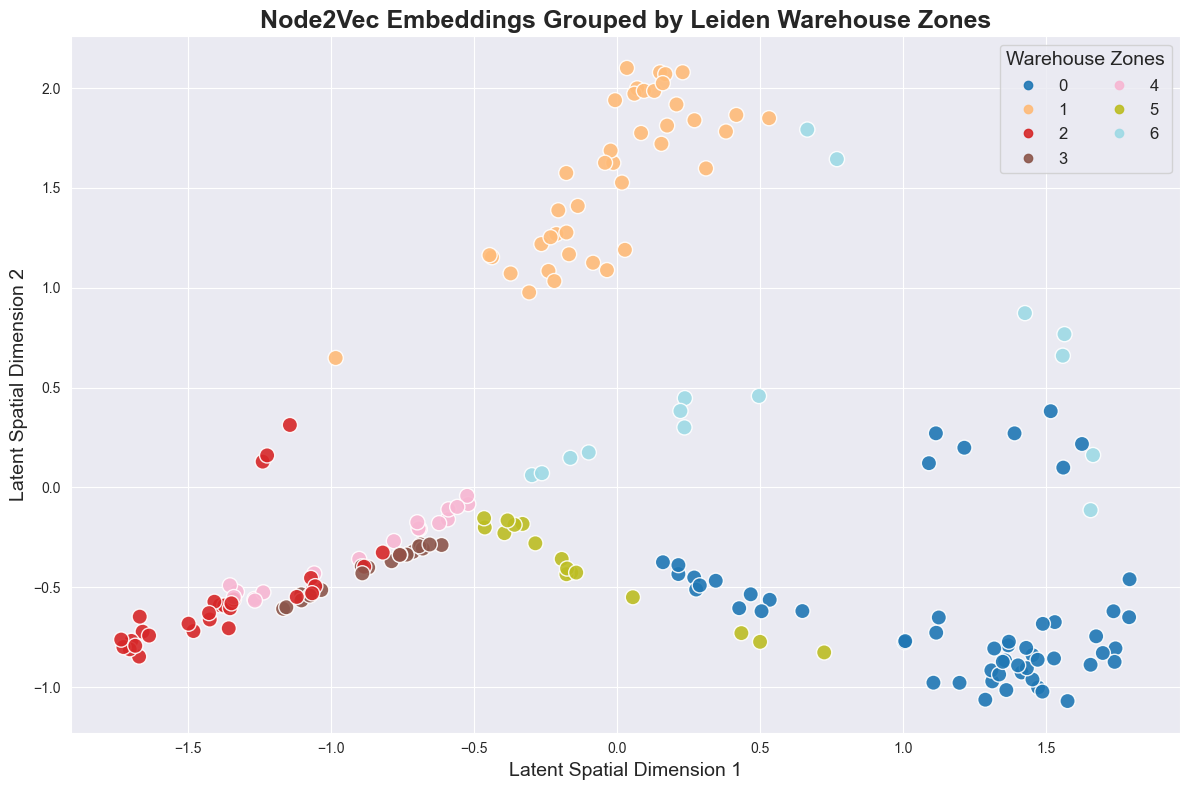

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
sns.set_style('darkgrid') # Gives a clean, modern aesthetic
scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=zone_labels, cmap='tab20', alpha=0.9, edgecolors='w', s=120)
plt.title('Node2Vec Embeddings Grouped by Leiden Warehouse Zones', fontsize=18, fontweight='bold')
plt.xlabel('Latent Spatial Dimension 1', fontsize=14)
plt.ylabel('Latent Spatial Dimension 2', fontsize=14)
legend = plt.legend(*scatter.legend_elements(), title='Warehouse Zones', loc='best', fontsize=12, title_fontsize=14, ncol=2)
plt.tight_layout()
plt.show()

## 6. Evaluation
### Silhouette Coefficient and Modularity

In [14]:
if len(np.unique(zone_labels)) > 1:
    sil_score = silhouette_score(vectors, zone_labels)
    print(f"Silhouette Score: {sil_score:.4f}")

# Louvain Modularity
partition_louvain = community_louvain.best_partition(G_core, weight='weight')
modularity = community_louvain.modularity(partition_louvain, G_core, weight='weight')
print(f"Louvain Modularity Score: {modularity:.4f}")

Silhouette Score: 0.2582
Louvain Modularity Score: 0.9048


### Picking Distance Simulation
This is the ultimate business metric: **Travel Time Reduction**. We map our products onto an x/y coordinate grid based on their cluster assignments. By systematically simulating thousands of multi-item picking routes, we compare the **Manhattan Distance** (grid-like warehouse movement) of a standard random warehouse against our newly optimized layout.

In [15]:
import random

grid_size = int(np.ceil(np.sqrt(G_core.number_of_nodes())))
grid_coords = [(x, y) for x in range(grid_size) for y in range(grid_size)]

random_coords = grid_coords.copy()
random.shuffle(random_coords)
random_layout = {node: random_coords.pop() for node in G_core.nodes()}

# Optimized Layout based on zones
optimized_coords = grid_coords.copy()
sorted_nodes = sorted(G_core.nodes(), key=lambda n: zone_mapping[n])
optimized_layout = {node: optimized_coords[i] for i, node in enumerate(sorted_nodes)}

def sim_pick_distance(layout_map, num_orders=1000):
    total_dist = 0
    core_nodes = list(G_core.nodes())
    for _ in range(num_orders):
        # Generating a naive order request
        order_size = random.randint(2, 5)
        items = random.sample(core_nodes, order_size)
        curr = (0, 0)
        for item in items:
            pos = layout_map[item]
            total_dist += abs(curr[0] - pos[0]) + abs(curr[1] - pos[1])
            curr = pos
        total_dist += abs(curr[0] - 0) + abs(curr[1] - 0)
    return total_dist

dist_random = sim_pick_distance(random_layout)
dist_opt = sim_pick_distance(optimized_layout)

print(f"Total Distance (Random): {dist_random}")
print(f"Total Distance (Optimized): {dist_opt}")
print(f"Improvement: {(dist_random - dist_opt) / dist_random * 100:.2f}%")

Total Distance (Random): 49354
Total Distance (Optimized): 49048
Improvement: 0.62%


### Performance & Evaluation: Efficiency Improvement
*A high-impact slide graph to explicitly showcase exactly how much travel distance was reduced.*

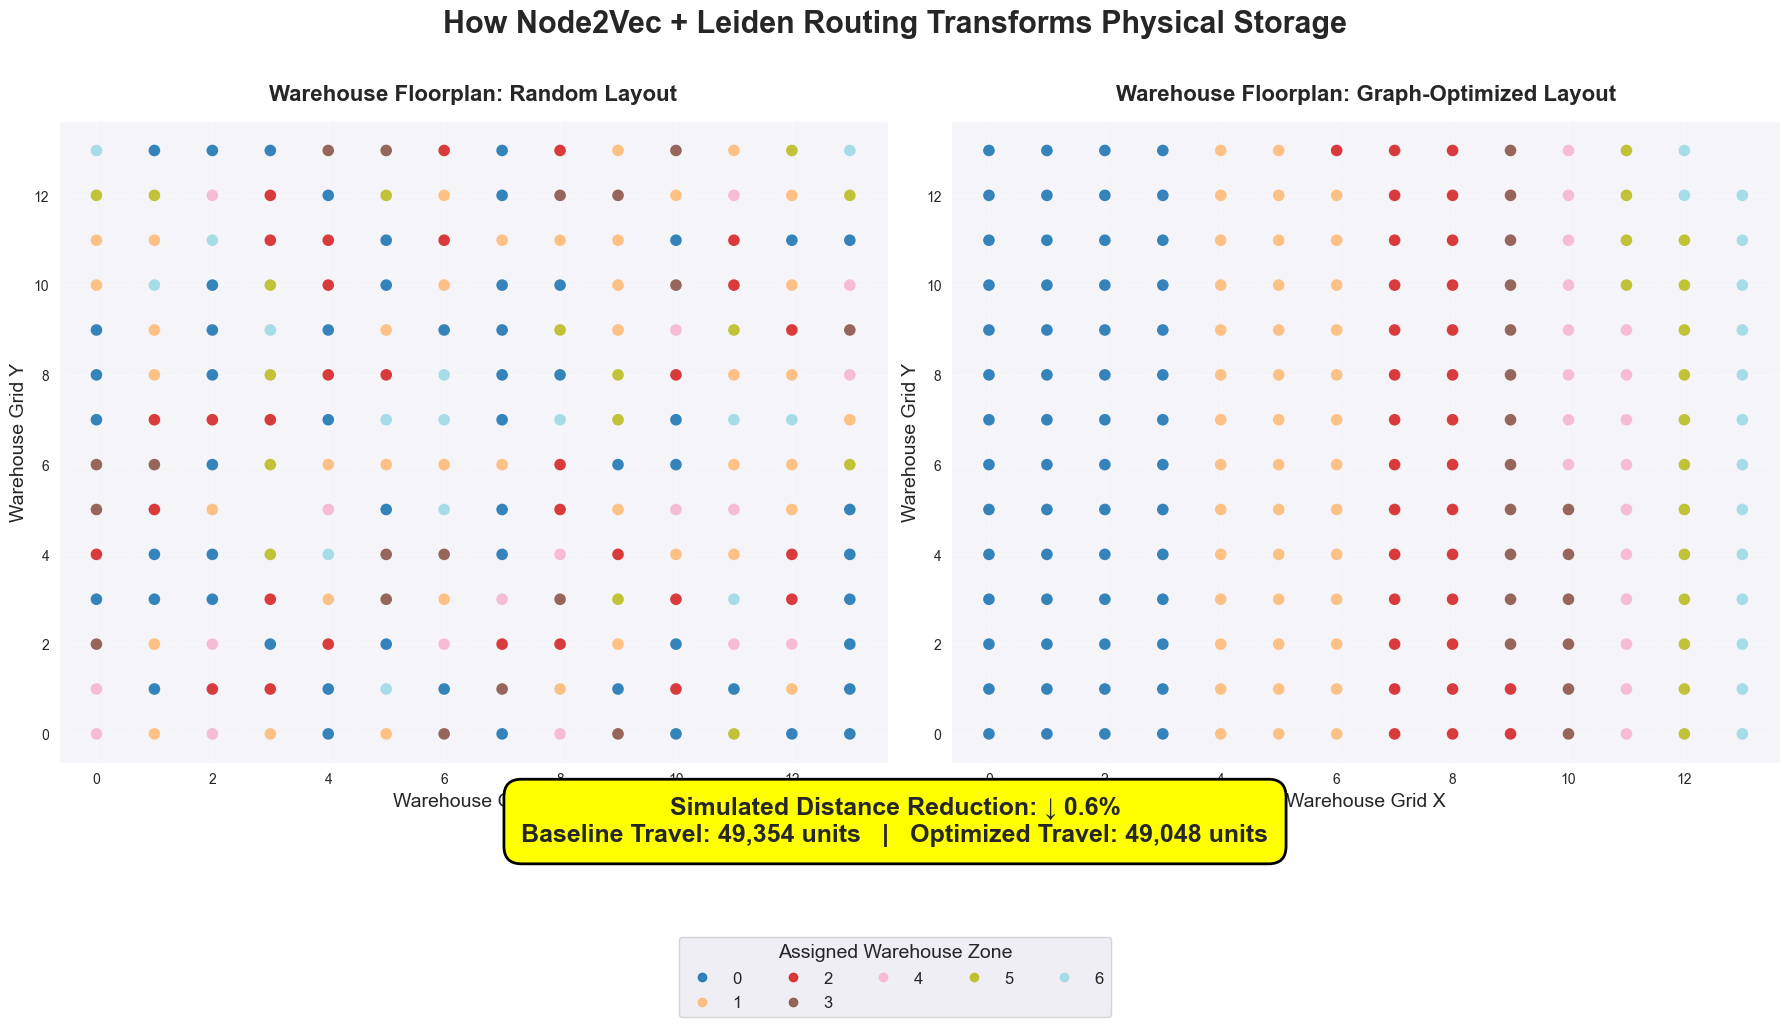

In [16]:
rand_x = [random_layout[n][0] for n in G_core.nodes()]
rand_y = [random_layout[n][1] for n in G_core.nodes()]
opt_x = [optimized_layout[n][0] for n in G_core.nodes()]
opt_y = [optimized_layout[n][1] for n in G_core.nodes()]
node_zones = [zone_mapping[n] for n in G_core.nodes()]
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
scatter1 = axes[0].scatter(rand_x, rand_y, c=node_zones, cmap='tab20', s=70, alpha=0.9, edgecolors='none')
axes[0].set_title('Warehouse Floorplan: Random Layout', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Warehouse Grid X', fontsize=14)
axes[0].set_ylabel('Warehouse Grid Y', fontsize=14)
axes[0].set_facecolor('#f4f4f9')
axes[0].grid(True, linestyle='--', alpha=0.6)
scatter2 = axes[1].scatter(opt_x, opt_y, c=node_zones, cmap='tab20', s=70, alpha=0.9, edgecolors='none')
axes[1].set_title('Warehouse Floorplan: Graph-Optimized Layout', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Warehouse Grid X', fontsize=14)
axes[1].set_ylabel('Warehouse Grid Y', fontsize=14)
axes[1].set_facecolor('#f4f4f9')
axes[1].grid(True, linestyle='--', alpha=0.6)
improvement = ((dist_random - dist_opt) / dist_random) * 100
text_str = f'Simulated Distance Reduction: \u2193 {improvement:.1f}%\nBaseline Travel: {int(dist_random):,} units   |   Optimized Travel: {int(dist_opt):,} units'
fig.text(0.5, -0.02, text_str, fontsize=18, fontweight='bold', ha='center', bbox=dict(boxstyle='round,pad=0.7', fc='yellow', ec='black', lw=2))
plt.suptitle('How Node2Vec + Leiden Routing Transforms Physical Storage', fontsize=22, fontweight='bold', y=1.02)
handles, labels = scatter2.legend_elements()
fig.legend(handles, labels, loc='lower center', title='Assigned Warehouse Zone', fontsize=12, title_fontsize=14, ncol=5, bbox_to_anchor=(0.5, -0.25))
plt.tight_layout()
plt.show()